In [1]:
from astropy.table import Table

t = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata.fits", hdu=1)
print(t.colnames)
print(t[:5])  # preview first 5 rows

['TARGETID', 'RA', 'DEC', 'DESI_TARGET', 'SPECTYPE', 'Z', 'ZWARN']
    TARGETID          RA        DEC     ... SPECTYPE         Z          ZWARN
---------------- ----------- ---------- ... -------- ------------------ -----
2368701667999750 260.8449464 57.0242807 ...   GALAXY 1.4983319292975803     0
2368786908839943 134.3885965 64.2221988 ...   GALAXY   1.49658374847844     0
2368789538668549 134.1554822 64.6208963 ...   GALAXY  1.341867321039909     4
2376125435084800     322.686    -8.7557 ...   GALAXY   1.02261915483918     0
2376164282728448    137.4895    -6.9718 ...   GALAXY 1.0253667671522346     0


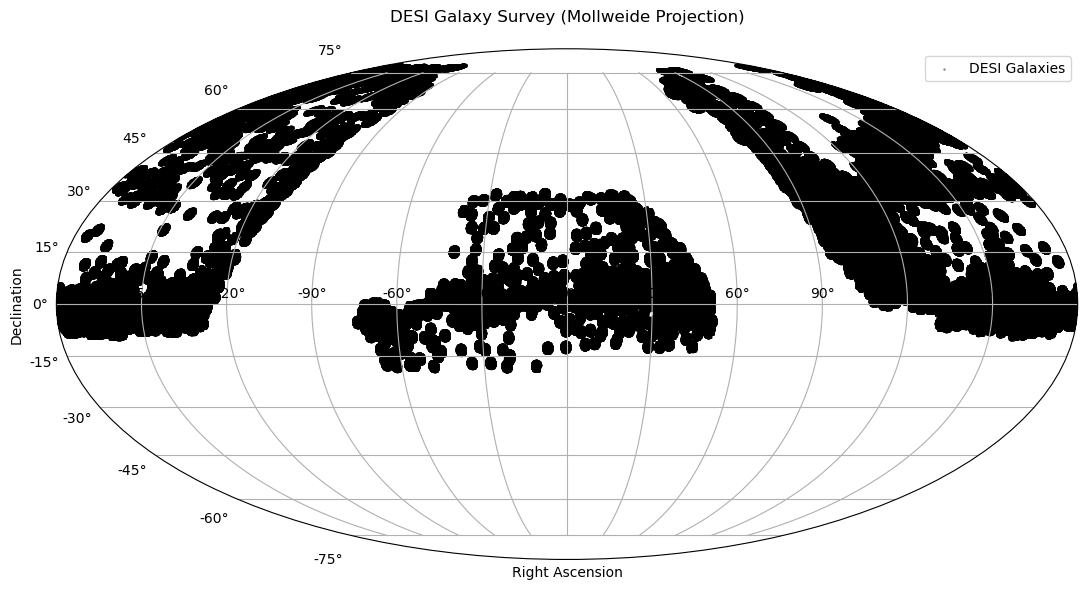

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# === Load DESI Galaxy Metadata === #
galaxy_data = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata.fits")

# Extract RA/DEC in degrees and convert to radians
ra = np.deg2rad(galaxy_data['RA'])
dec = np.deg2rad(galaxy_data['DEC'])

# Convert RA to [-π, π] and flip
ra = np.remainder(ra + 2*np.pi, 2*np.pi)  # wrap RA around 2π
ra[ra > np.pi] -= 2*np.pi                # convert to [-π, π]
ra = -ra                                 # flip for Mollweide

# === Plot === #
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')
ax.scatter(ra, dec, s=1, alpha=0.3, color='black', label='DESI Galaxies')

ax.set_title('DESI Galaxy Survey (Mollweide Projection)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.legend(frameon=True)  # ← default legend placement
plt.tight_layout()
plt.show()

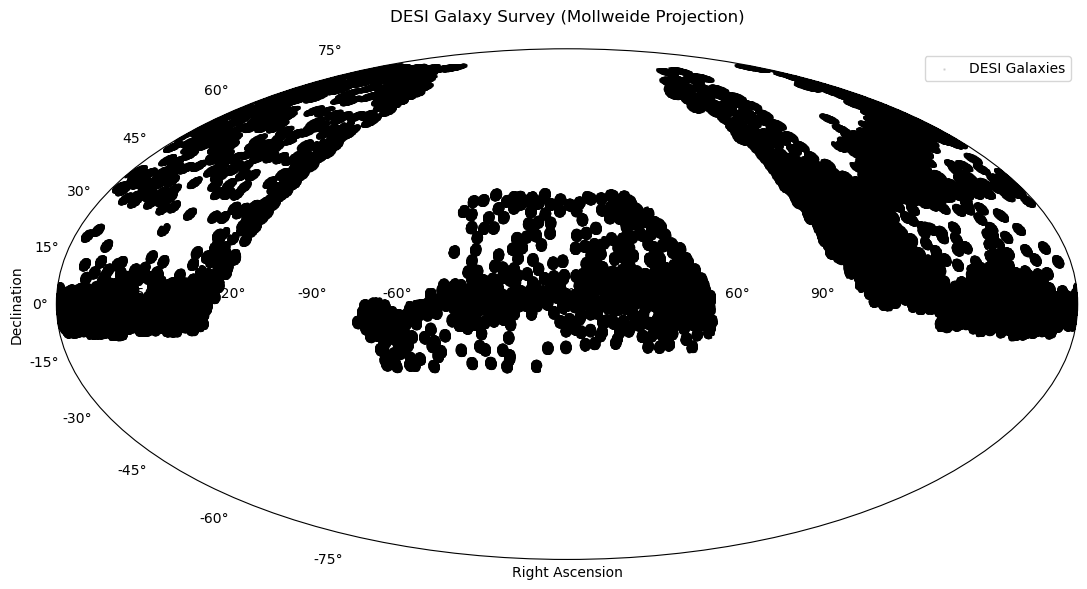

In [3]:
# === Plot === #
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')
ax.scatter(ra, dec, s=1, alpha=0.1, color='black', label='DESI Galaxies')

ax.set_title('DESI Galaxy Survey (Mollweide Projection)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.legend(frameon=True)  # ← default legend placement
plt.tight_layout()
plt.show()

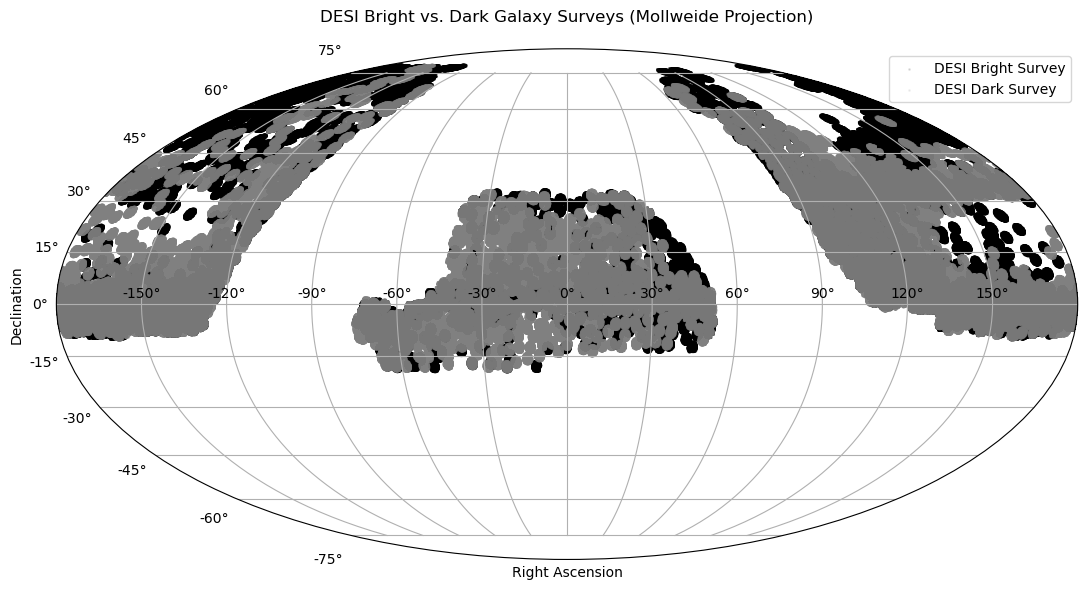

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

def prepare_coords(table):
    ra = np.deg2rad(table['RA'])
    dec = np.deg2rad(table['DEC'])

    # Convert RA to [-π, π] and flip
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    ra = -ra
    return ra, dec

# === Load DESI Bright Data === #
bright_path = "DES5YR_DESI_match_data/desi_galaxy_metadata.fits"
bright_data = Table.read(bright_path)
ra_bright, dec_bright = prepare_coords(bright_data)

# === Load DESI Dark Data === #
dark_path = "DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits"
dark_data = Table.read(dark_path)
ra_dark, dec_dark = prepare_coords(dark_data)

# === Plot === #
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Plot both with different colors
ax.scatter(ra_bright, dec_bright, s=1, alpha=0.1, color='black', label='DESI Bright Survey')
ax.scatter(ra_dark, dec_dark, s=1, alpha=0.1, color='grey', label='DESI Dark Survey')

ax.set_title('DESI Bright vs. Dark Galaxy Surveys (Mollweide Projection)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

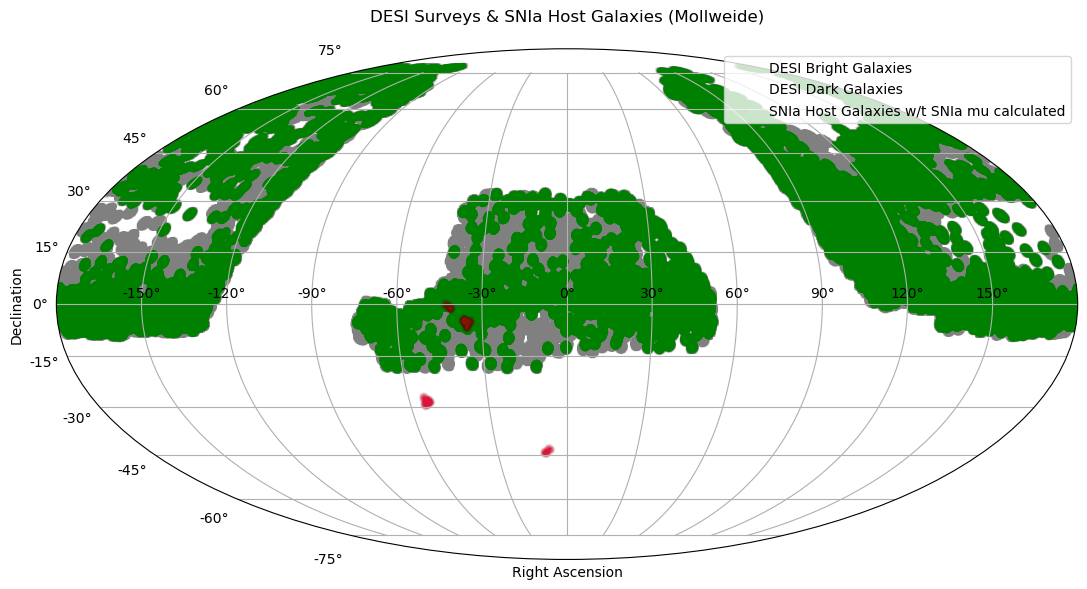

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table

def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

# === Load DESI Bright ===
bright = Table.read("desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load SNIa Metadata CSV ===
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")  # UPDATE with real path

# Filter out invalid host coordinates
valid_hosts = (sn_df['HOST_RA'] != -999) & (sn_df['HOST_DEC'] != -999)
host_ra = sn_df.loc[valid_hosts, 'HOST_RA'].values
host_dec = sn_df.loc[valid_hosts, 'HOST_DEC'].values
ra_host, dec_host = prepare_coords(host_ra, host_dec)

# === Plot all ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

ax.scatter(ra_bright, dec_bright, s=10, alpha=0.002, color='green', label='DESI Bright Galaxies')
ax.scatter(ra_dark, dec_dark, s=10, alpha=0.005, color='gray', label='DESI Dark Galaxies')
ax.scatter(ra_host, dec_host, s=10, alpha=0.01, color='crimson', label='SNIa Host Galaxies w/t SNIa mu calculated')

ax.set_title('DESI Surveys & SNIa Host Galaxies (Mollweide)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
ax.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

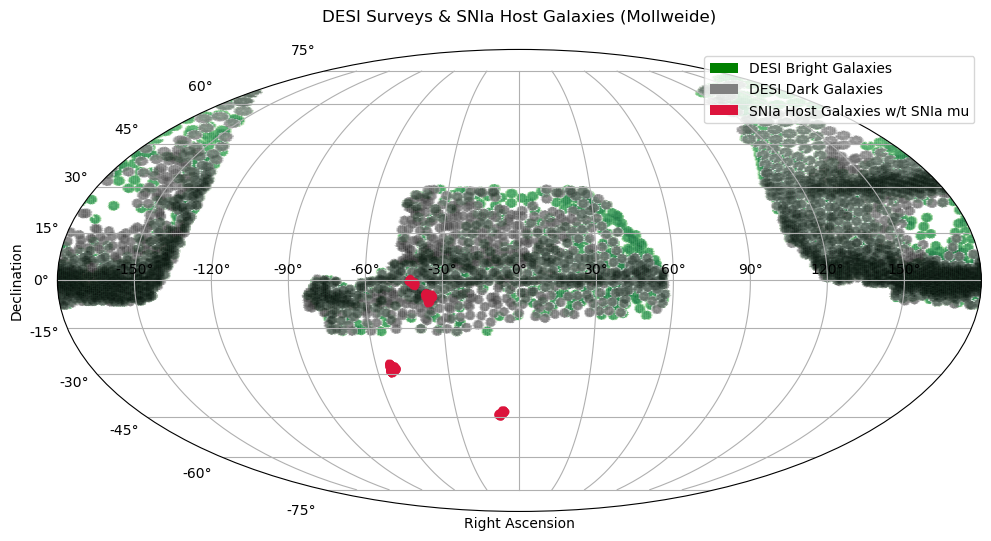

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

# === Load DESI Bright ===
bright = Table.read("desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load SNIa Metadata CSV ===
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid host coordinates
valid_hosts = (sn_df['HOST_RA'] != -999) & (sn_df['HOST_DEC'] != -999)
host_ra = sn_df.loc[valid_hosts, 'HOST_RA'].values
host_dec = sn_df.loc[valid_hosts, 'HOST_DEC'].values
ra_host, dec_host = prepare_coords(host_ra, host_dec)

# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()
x_host, y_host = ra_host.flatten(), dec_host.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())

# SNIa Hosts (scatter instead of density)
ax.scatter(x_host, y_host, s=10, color='crimson', alpha=0.6, label='SNIa Host Galaxies w/t SNIa mu')

# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='crimson', label='SNIa Host Galaxies w/t SNIa mu', alpha=1)
]
ax.legend(handles=legend_elements, loc='upper right')

# Plot settings
ax.set_title('DESI Surveys & SNIa Host Galaxies (Mollweide)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

**Colormap Options for hexbin**

Matplotlib provides many colormaps. You can pass any of these names to the `cmap` parameter. Some common ones:
- **Sequential:** viridis, plasma, inferno, magma, cividis, YlOrBr, Greys, Blues, Reds
- **Diverging:** RdYlBu, RdBu, coolwarm, PiYG, PRGn
- **Qualitative:** tab10, Set1, Accent, Paired
- **Cyclic:** hsv
- **Miscellaneous:** gist_yarg, terrain, gist_ncar

For a full list, see the following code cell.
</VSCode.Cell>
<VSCode.Cell language="python">
import matplotlib.pyplot as plt
# List all available colormaps
print(plt.colormaps())


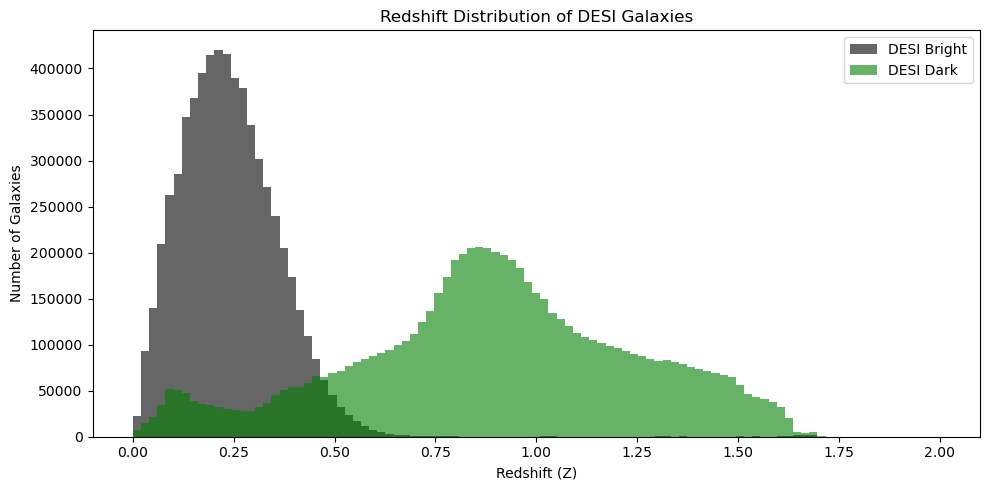

In [3]:
import matplotlib.pyplot as plt
from astropy.table import Table

def load_redshift(path, label):
    data = Table.read(path)
    mask = (data['SPECTYPE'] == 'GALAXY') & (data['ZWARN'] == 0)
    return data['Z'][mask], label

# === Load Bright & Dark Redshifts === #
z_bright, label_bright = load_redshift("DES5YR_DESI_match_data/desi_galaxy_metadata.fits", "DESI Bright")
z_dark, label_dark = load_redshift("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits", "DESI Dark")

# === Plot === #
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 2, 100)  # you can change max if higher-z sources exist

plt.hist(z_bright, bins=bins, alpha=0.3, label=label_bright, color='black', histtype='stepfilled')
plt.hist(z_dark, bins=bins, alpha=0.3, label=label_dark, color='green', histtype='stepfilled')

plt.title("Redshift Distribution of DESI Galaxies")
plt.xlabel("Redshift (Z)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.tight_layout()
plt.show()

116


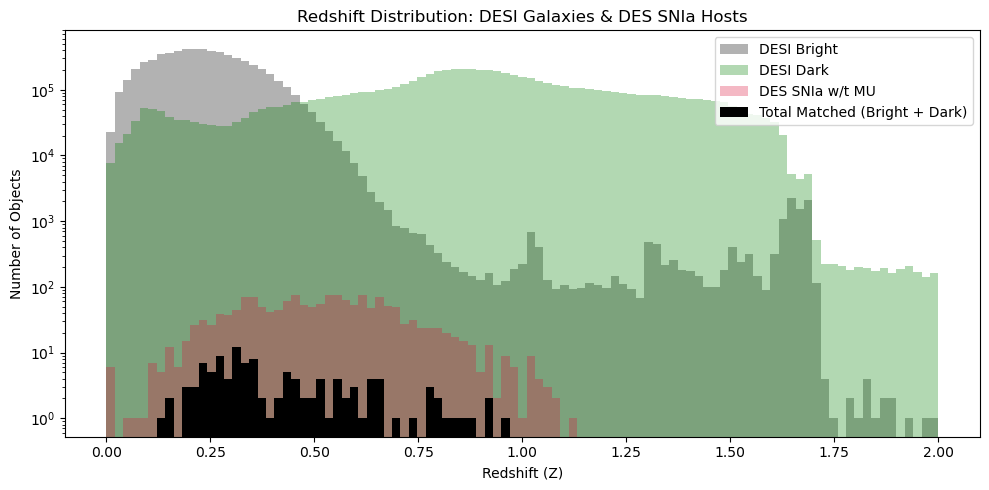

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

def load_redshift(path, label):
    data = Table.read(path)
    mask = (data['SPECTYPE'] == 'GALAXY') & (data['ZWARN'] == 0)
    return data['Z'][mask], label

# === Load Bright & Dark DESI Galaxies === #
z_bright, label_bright = load_redshift("DES5YR_DESI_match_data/desi_galaxy_metadata.fits", "DESI Bright")
z_dark, label_dark = load_redshift("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits", "DESI Dark")

# === Load SNIa Host Galaxy Redshifts from CSV === #
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")  # replace path
z_host = sn_df.loc[sn_df['HOST_ZSPEC'] != -999, 'HOST_ZSPEC'].values
label_host = "DES SNIa w/t MU"

# === Plot === #
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 2, 100)

plt.hist(z_bright, bins=bins, alpha=0.3, label=label_bright, color='black', histtype='stepfilled')
plt.hist(z_dark, bins=bins, alpha=0.3, label=label_dark, color='green', histtype='stepfilled')
plt.hist(z_host, bins=bins, alpha=0.3, label=label_host, color='crimson', histtype='stepfilled')
plt.hist(z_total, bins=bins, alpha=1, label='Total Matched (Bright + Dark)', color='black', histtype='stepfilled')
print(len(z_total))


plt.title("Redshift Distribution: DESI Galaxies & DES SNIa Hosts")
plt.xlabel("Redshift (Z)")
plt.ylabel("Number of Objects")
plt.legend(loc='upper right')
plt.yscale("log")
plt.tight_layout()
plt.show()

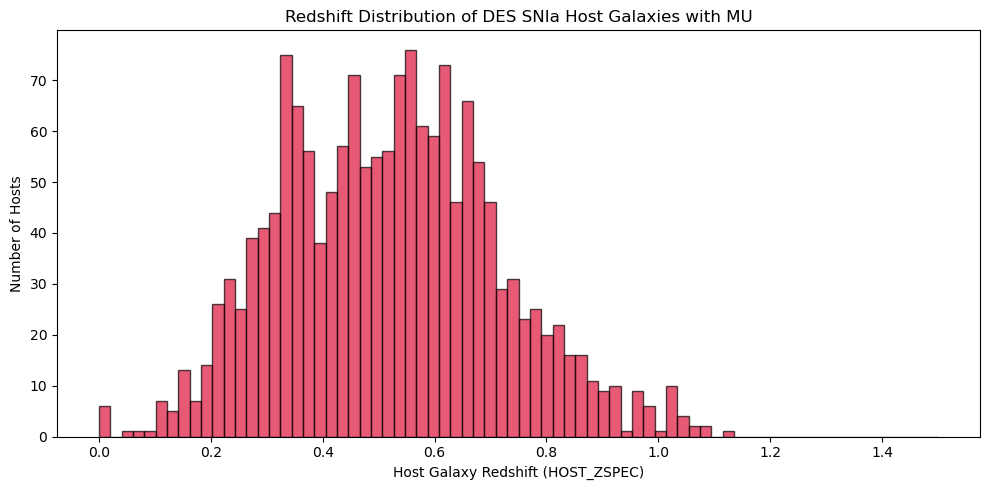

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Load Supernova Metadata CSV === #
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")  # <-- update this path

# === Filter for valid host galaxy redshifts === #
valid_mask = sn_df['HOST_ZSPEC'] != -999
z_host = sn_df.loc[valid_mask, 'HOST_ZSPEC'].values

# === Plot === #
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 1.5, 75)  # Adjust upper limit as needed

plt.hist(z_host, bins=bins, alpha=0.7, color='crimson', edgecolor='black')

plt.title("Redshift Distribution of DES SNIa Host Galaxies with MU")
plt.xlabel("Host Galaxy Redshift (HOST_ZSPEC)")
plt.ylabel("Number of Hosts")
plt.tight_layout()
plt.show()

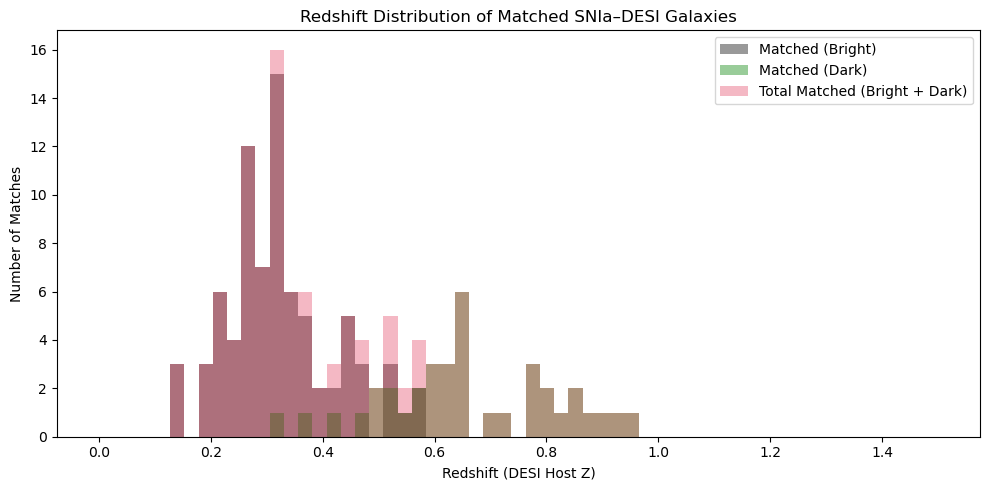

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Load Matched CSV Files ===
bright_df = pd.read_csv("/global/homes/m/myc21/first_paper/DES5YR_DESI_match_data/desi_matched_sn.csv")
dark_df = pd.read_csv("/global/homes/m/myc21/first_paper/DES5YR_DESI_match_data/desi_matched_sn_dark.csv")

# === Extract Good DESI Galaxy Redshifts ===
z_bright = bright_df.loc[bright_df['ZWARN'] == 0, 'Z'].values
z_dark = dark_df.loc[dark_df['ZWARN'] == 0, 'Z'].values

# === Combine both for total histogram ===
z_total = np.concatenate([z_bright, z_dark])

# === Plot ===
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 1.5, 60)

plt.hist(z_bright, bins=bins, alpha=0.4, label='Matched (Bright)', color='black', histtype='stepfilled')
plt.hist(z_dark, bins=bins, alpha=0.4, label='Matched (Dark)', color='green', histtype='stepfilled')
plt.hist(z_total, bins=bins, alpha=0.3, label='Total Matched (Bright + Dark)', color='crimson', histtype='stepfilled')

plt.title("Redshift Distribution of Matched SNIa–DESI Galaxies")
plt.xlabel("Redshift (DESI Host Z)")
plt.ylabel("Number of Matches")
plt.legend()
plt.tight_layout()
plt.show()

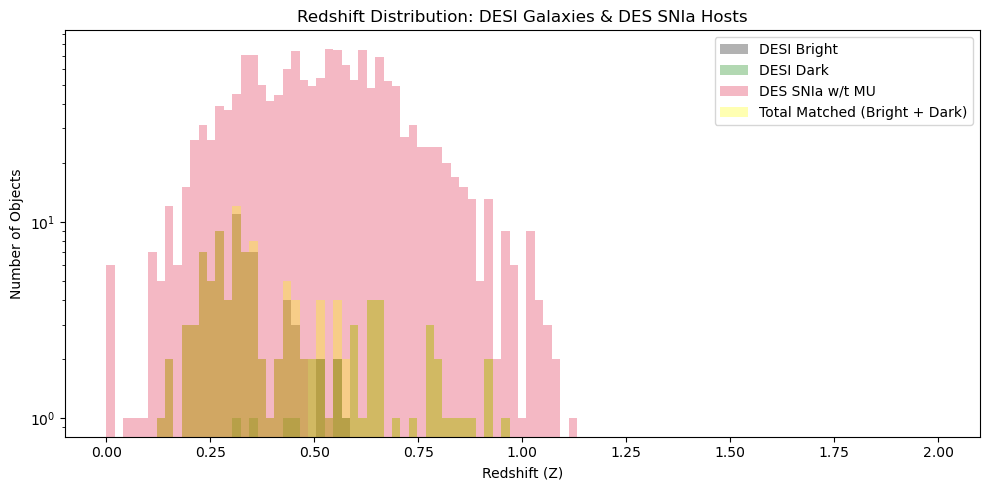

In [17]:
# === Plot === #
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 2, 100)

plt.hist(z_bright, bins=bins, alpha=0.3, label=label_bright, color='black', histtype='stepfilled')
plt.hist(z_dark, bins=bins, alpha=0.3, label=label_dark, color='green', histtype='stepfilled')
plt.hist(z_host, bins=bins, alpha=0.3, label=label_host, color='crimson', histtype='stepfilled')
plt.hist(z_total, bins=bins, alpha=0.3, label='Total Matched (Bright + Dark)', color='yellow', histtype='stepfilled')


plt.title("Redshift Distribution: DESI Galaxies & DES SNIa Hosts")
plt.xlabel("Redshift (Z)")
plt.ylabel("Number of Objects")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

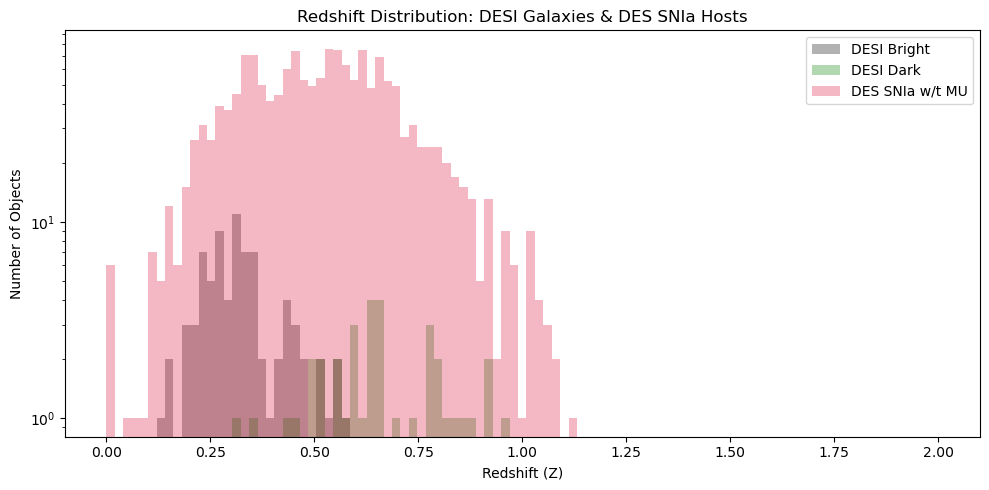

In [18]:
# === Plot === #
plt.figure(figsize=(10, 5))
bins = np.linspace(0, 2, 100)

plt.hist(z_bright, bins=bins, alpha=0.3, label=label_bright, color='black', histtype='stepfilled')
plt.hist(z_dark, bins=bins, alpha=0.3, label=label_dark, color='green', histtype='stepfilled')
plt.hist(z_host, bins=bins, alpha=0.3, label=label_host, color='crimson', histtype='stepfilled')

plt.title("Redshift Distribution: DESI Galaxies & DES SNIa Hosts")
plt.xlabel("Redshift (Z)")
plt.ylabel("Number of Objects")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()